# Step 2 - Speed vs. time, and speed at 10 s
> Using matplotlib, graph the speed of the car vs time. Use that graph to find the speed of the car at 10 s.

`SME_TRQSPD_Speed` is motor RPM. Converted to m/s with:

$v = mRPM \cdot \frac{12}{41} \cdot \frac{2\pi}{60} \cdot 0.2\,m$

In [1]:
import polars as pL
import numpy as np
import matplotlib.pyplot as plt

pd = pL.read_parquet("./software-data.parquet")
pd = pd.fill_null(strategy="forward")

rpm = pd["SME_TRQSPD_Speed"]
time = pd["Time"]

gear_ratio = 12/41
radius = .2                             #in meters

def meters_second(rpm):
    speed_mps = (rpm * gear_ratio * 2 * 3.14159 * radius) / 60  # Convert rpm to m/s
    return speed_mps

speed = meters_second(rpm)
moving = speed > 0.1

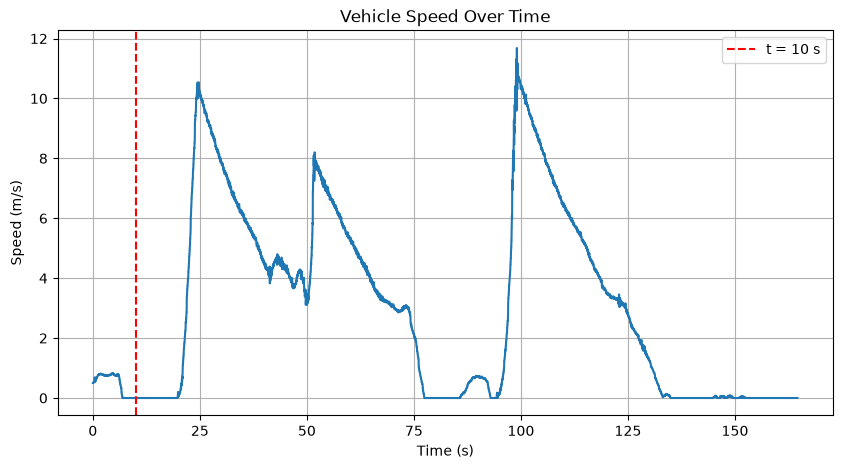

In [2]:
plt.figure(figsize=(10, 5))
plt.plot(time, speed)
plt.axvline(10, color='red', linestyle='--', label="t = 10 s")
plt.xlabel("Time (s)")
plt.ylabel("Speed (m/s)")
plt.title("Vehicle Speed Over Time")
plt.legend()
plt.grid(True)
plt.show()

## Answer: 0 m/s - the car is stopped at 10 s

- The graph is flat at 0 around 10 s.